# CSD hackathon — Stage 1 (détection)

Notebook exécutable de haut en bas : générer un dataset d'images CSD + masques, le recharger, le visualiser, puis prédire les masques par transformée de Hough.

> Les données de démo sont écrites dans `data/nb_demo` (petit `n`), séparé de `data/train`, et régénérées avec `overwrite=True` pour que ce notebook se relance proprement.

In [1]:
import pathlib
import sys

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Rendre le package top-level ``csd`` importable, quel que soit le cwd du kernel.
REPO = pathlib.Path.cwd()
if not (REPO / "csd").is_dir():
    REPO = REPO.parent  # au cas où le notebook tourne depuis un sous-dossier
sys.path.insert(0, str(REPO))

import csd

print("csd importé depuis :", REPO / "csd")
print("API publique :", ", ".join(csd.__all__))

csd importé depuis : C:\Users\julie\OneDrive\Documents\Explorations\challenge\csd
API publique : new_experiment, Experiment, ChallengeConfig, CHALLENGE, GeneratorConfig, GENERATOR, CSDSimulator, DriftMatrix, RegionContrastModel, Region, default_working_point, GATES, PLUNGERS, BARRIERS, generate_dataset, load_dataset, DEFAULT_SCAN_WINDOW, ScanWindow, build_interdots, render_csd, generate_csd_and_label


## ✅ Validation de la commande `generate_data.py`

Affiche les images **réellement produites** par la commande
`uv run python starter/stage1_detection/generate_data.py --out data/train`.
C'est le contrôle visuel pour valider que la commande a bien tourné.

> Si la cellule s'arrête avec un message, c'est que `data/train` n'a pas de dataset complet : (re)lance la commande, puis ré-exécute la cellule.

commande OK -> n = 2   image_shape = [150, 150]   mask = binary
images: (2, 150, 150) float32    masks: (2, 150, 150) uint8


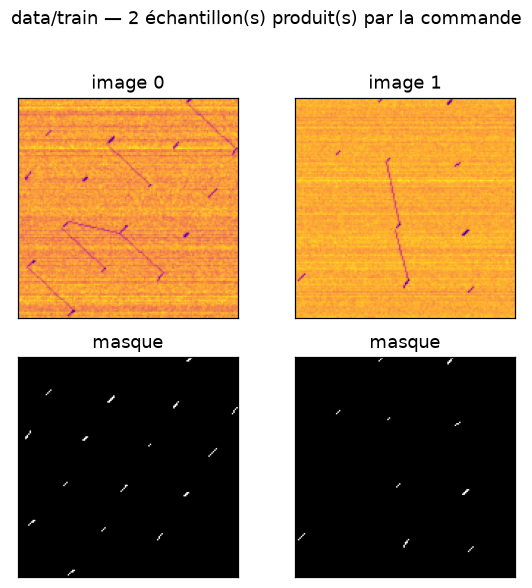

In [2]:
from csd import load_dataset

TRAIN_DIR = REPO / "data" / "train"
if not (TRAIN_DIR / "meta.json").exists():
    raise FileNotFoundError(
        f"Pas de dataset complet dans {TRAIN_DIR}.\n"
        "Lance d'abord (vide le dossier au besoin) :\n"
        "  uv run python starter/stage1_detection/generate_data.py --n 2 --out data/train"
    )

ds_train = load_dataset(TRAIN_DIR)
imgs, msks, meta_t = ds_train["images"], ds_train["masks"], ds_train["meta"]
print(f"commande OK -> n = {meta_t['n']}   image_shape = {meta_t['image_shape']}   mask = {meta_t['mask']}")
print(f"images: {imgs.shape} {imgs.dtype}    masks: {msks.shape} {msks.dtype}")

k = min(6, len(imgs))
fig, axes = plt.subplots(2, k, figsize=(2.6 * k, 5.2), squeeze=False)
for col in range(k):
    axes[0, col].imshow(imgs[col], origin="lower", cmap="plasma")
    axes[0, col].set_title(f"image {col}")
    axes[1, col].imshow(msks[col], origin="lower", cmap="gray")
    axes[1, col].set_title("masque")
    for ax in axes[:, col]:
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle(f"data/train — {meta_t['n']} échantillon(s) produit(s) par la commande", y=1.02)
fig.tight_layout()
plt.show()

## Stage 1 — détection : générer un dataset

`generate_dataset(n, out_dir, seed=..., overwrite=...)` écrit un dossier simple :
`images.npy` / `masks.npy` / `sticks.jsonl` / `meta.json`.

C'est exactement ce que fait `starter/stage1_detection/generate_data.py` ; ici on appelle la fonction directement avec un petit `n` pour aller vite.

In [3]:
from csd import generate_dataset, load_dataset

DEMO_DIR = REPO / "data" / "nb_demo"

out = generate_dataset(n=8, out_dir=DEMO_DIR, seed=0, overwrite=True)
print(f"dataset écrit dans {out}/")
print(sorted(p.name for p in out.iterdir()))

dataset écrit dans C:\Users\julie\OneDrive\Documents\Explorations\challenge\data\nb_demo/
['images.npy', 'masks.npy', 'meta.json', 'sticks.jsonl']


### Recharger et inspecter

`load_dataset` renvoie un dict `{images, masks, sticks, meta}`. Les tableaux sont memory-mapped (lecture paresseuse), donc c'est bon marché même sur un gros dataset.

In [4]:
ds = load_dataset(DEMO_DIR)
images, masks, sticks, meta = ds["images"], ds["masks"], ds["sticks"], ds["meta"]

print(f"n = {meta['n']}   image_shape = {meta['image_shape']}   mask = {meta['mask']}")
print(f"images: {images.shape} {images.dtype}    masks: {masks.shape} {masks.dtype}")
print(f"image 0 : {len(sticks[0]['sticks'])} interdots ; premier stick =")
sticks[0]["sticks"][0]

n = 8   image_shape = [150, 150]   mask = binary
images: (8, 150, 150) float32    masks: (8, 150, 150) uint8
image 0 : 16 interdots ; premier stick =


{'x': 0.07230123597765267, 'y': 0.005587367514022208, 'length': 0.011400814635412098, 'width': 0.0020638165527890407, 'theta': 0.6638670152387544, 'intensity': -9.154298635459124, 'i': 4, 'j': 5}

### Visualiser images + masques

Ligne du haut : l'image CSD brute (les interdots sont les *creux sombres*). Ligne du bas : le masque des pixels interdots — c'est la cible à prédire dans le challenge 1.

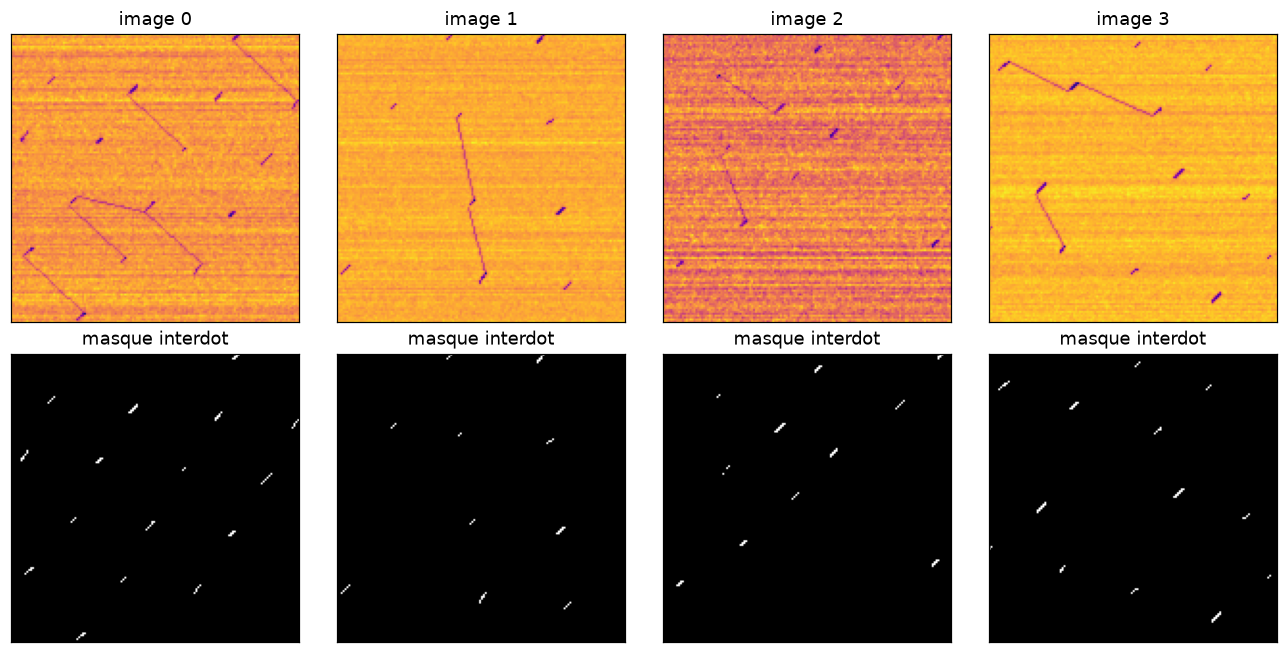

In [5]:
k = min(4, len(images))
fig, axes = plt.subplots(2, k, figsize=(3 * k, 6))
axes = np.atleast_2d(axes)
for col in range(k):
    axes[0, col].imshow(images[col], origin="lower", cmap="plasma")
    axes[0, col].set_title(f"image {col}")
    axes[1, col].imshow(masks[col], origin="lower", cmap="gray")
    axes[1, col].set_title("masque interdot")
    for ax in axes[:, col]:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()
plt.show()

### Métadonnées par stick

`sticks.jsonl` donne, pour chaque image, la liste des interdots avec position (`x`,`y`), longueur, largeur, angle `theta`, intensité et indices de ligne de charge. Libre à vous de vous en servir en plus du masque.

In [6]:
rec = sticks[0]
print(f"image_id = {rec['image_id']}   ({len(rec['sticks'])} interdots)")
for s in rec["sticks"][:3]:
    print(s)

image_id = 0   (16 interdots)
{'x': 0.07230123597765267, 'y': 0.005587367514022208, 'length': 0.011400814635412098, 'width': 0.0020638165527890407, 'theta': 0.6638670152387544, 'intensity': -9.154298635459124, 'i': 4, 'j': 5}
{'x': 0.018090898427108572, 'y': 0.07333759568544797, 'length': 0.013154670377203812, 'width': 0.0018157502498207779, 'theta': 0.6972896641653642, 'intensity': -9.850618051343286, 'i': 5, 'j': 5}
{'x': 0.11500837472992691, 'y': 0.06353840754166895, 'length': 0.008780626105520222, 'width': 0.001366453401417309, 'theta': 0.733456558175723, 'intensity': -8.940164663895859, 'i': 5, 'j': 6}


### Détection des interdots par transformée de Hough

Seuillage des pixels sombres → `probabilistic_hough_line` restreinte à l'orientation des sticks (~45°) → tracé des segments.

Les paramètres sont réglés par recherche aléatoire pour maximiser le **Dice** moyen, sur un jeu séparé (`data/hough_tune`, seed 1) ; la grille est évaluée sur `nb_demo` (seed 0).
Colonne *comparaison* : vert = vrai positif, rouge = faux positif, bleu = faux négatif.

In [ ]:
from scipy.ndimage import binary_dilation, gaussian_filter
from skimage.draw import line as draw_line
from skimage.transform import probabilistic_hough_line


def hough_mask(
    image,
    sigma=0.5,
    k=4.0,
    k_fill=4.0,
    stick_theta=np.pi / 4,
    theta_tol=0.4,
    threshold=3,
    line_length=2,
    line_gap=1,
    dilate=1,
    seed=0,
):
    """Prédit un masque d'interdots via une transformée de Hough probabiliste.

    Args:
        image: Image CSD 2D brute (les interdots sont des creux sombres).
        sigma: Écart-type du lissage gaussien appliqué avant seuillage.
        k: Seuil de détection, en MAD sous la médiane, pour l'entrée de Hough.
        k_fill: Seuil (en MAD) des pixels gardés autour des segments détectés.
        stick_theta: Orientation attendue des sticks [rad] (repère origin="lower").
        theta_tol: Tolérance angulaire autour de ``stick_theta`` [rad].
        threshold: Nombre minimal de votes de l'accumulateur de Hough.
        line_length: Longueur minimale d'un segment [px].
        line_gap: Écart maximal entre pixels d'un même segment [px].
        dilate: Épaississement des segments tracés [px] avant le seuil ``k_fill``.
        seed: Graine du tirage aléatoire de ``probabilistic_hough_line``.

    Returns:
        Masque binaire uint8 de même forme que ``image``.
    """
    smooth = gaussian_filter(np.asarray(image, dtype=float), sigma)
    med = np.median(smooth)
    mad = 1.4826 * np.median(np.abs(smooth - med))
    depth = (med - smooth) / mad  # profondeur du creux, en unités de bruit

    # skimage paramètre une droite par l'angle de sa normale : theta_stick - pi/2.
    normal = stick_theta - np.pi / 2
    thetas = np.linspace(normal - theta_tol, normal + theta_tol, 41)
    segments = probabilistic_hough_line(
        depth > k,
        threshold=threshold,
        line_length=line_length,
        line_gap=line_gap,
        theta=thetas,
        rng=seed,
    )

    lines = np.zeros(image.shape, dtype=bool)
    for (x0, y0), (x1, y1) in segments:
        rr, cc = draw_line(y0, x0, y1, x1)
        lines[rr, cc] = True
    if dilate > 0:
        lines = binary_dilation(lines, iterations=dilate)
    mask = lines & (depth > k_fill)
    return mask.astype(np.uint8)


def dice(pred, target):
    """Score de Dice entre deux masques binaires (1.0 si les deux sont vides).

    Args:
        pred: Masque prédit.
        target: Masque cible.

    Returns:
        ``2·|P∩C| / (|P| + |C|)``.
    """
    pred, target = pred > 0, target > 0
    total = pred.sum() + target.sum()
    return 1.0 if total == 0 else float(2 * (pred & target).sum() / total)

In [5]:
TUNE_DIR = REPO / "data" / "hough_tune"
if not (TUNE_DIR / "meta.json").exists():
    generate_dataset(n=64, out_dir=TUNE_DIR, seed=1, overwrite=True)
tune = load_dataset(TUNE_DIR)
tune_images, tune_masks = np.asarray(tune["images"]), np.asarray(tune["masks"])


def mean_dice(params, imgs, msks):
    """Dice moyen par image de ``hough_mask(**params)`` sur un jeu d'images."""
    return float(np.mean([dice(hough_mask(im, **params), m) for im, m in zip(imgs, msks)]))


rng = np.random.default_rng(0)


def sample_params():
    """Tire une configuration aléatoire de ``hough_mask``."""
    return {
        "sigma": round(float(rng.uniform(0.0, 1.2)), 2),
        "k": round(float(rng.uniform(2.0, 8.0)), 2),
        "k_fill": round(float(rng.uniform(1.5, 6.0)), 2),
        "theta_tol": round(float(rng.uniform(0.1, 0.8)), 2),
        "threshold": int(rng.integers(1, 9)),
        "line_length": int(rng.integers(1, 7)),
        "line_gap": int(rng.integers(0, 4)),
        "dilate": int(rng.integers(0, 3)),
    }


N_TRIALS = 300
results = [(mean_dice({}, tune_images, tune_masks), {})]  # {} = paramètres par défaut
for _ in range(N_TRIALS):
    params = sample_params()
    results.append((mean_dice(params, tune_images, tune_masks), params))
best_tune, BEST_PARAMS = max(results, key=lambda r: r[0])

print("meilleurs paramètres :", BEST_PARAMS)
print(f"Dice hough_tune (réglage)    : défaut {results[0][0]:.3f} -> optimisé {best_tune:.3f}")
print(
    f"Dice nb_demo (hors réglage)  : défaut {mean_dice({}, images, masks):.3f}"
    f" -> optimisé {mean_dice(BEST_PARAMS, images, masks):.3f}"
)

meilleurs paramètres : {'sigma': 0.29, 'k': 2.72, 'k_fill': 5.01, 'theta_tol': 0.26, 'threshold': 5, 'line_length': 2, 'line_gap': 2, 'dilate': 1}
Dice hough_tune (réglage)    : défaut 0.512 -> optimisé 0.716
Dice nb_demo (hors réglage)  : défaut 0.519 -> optimisé 0.665


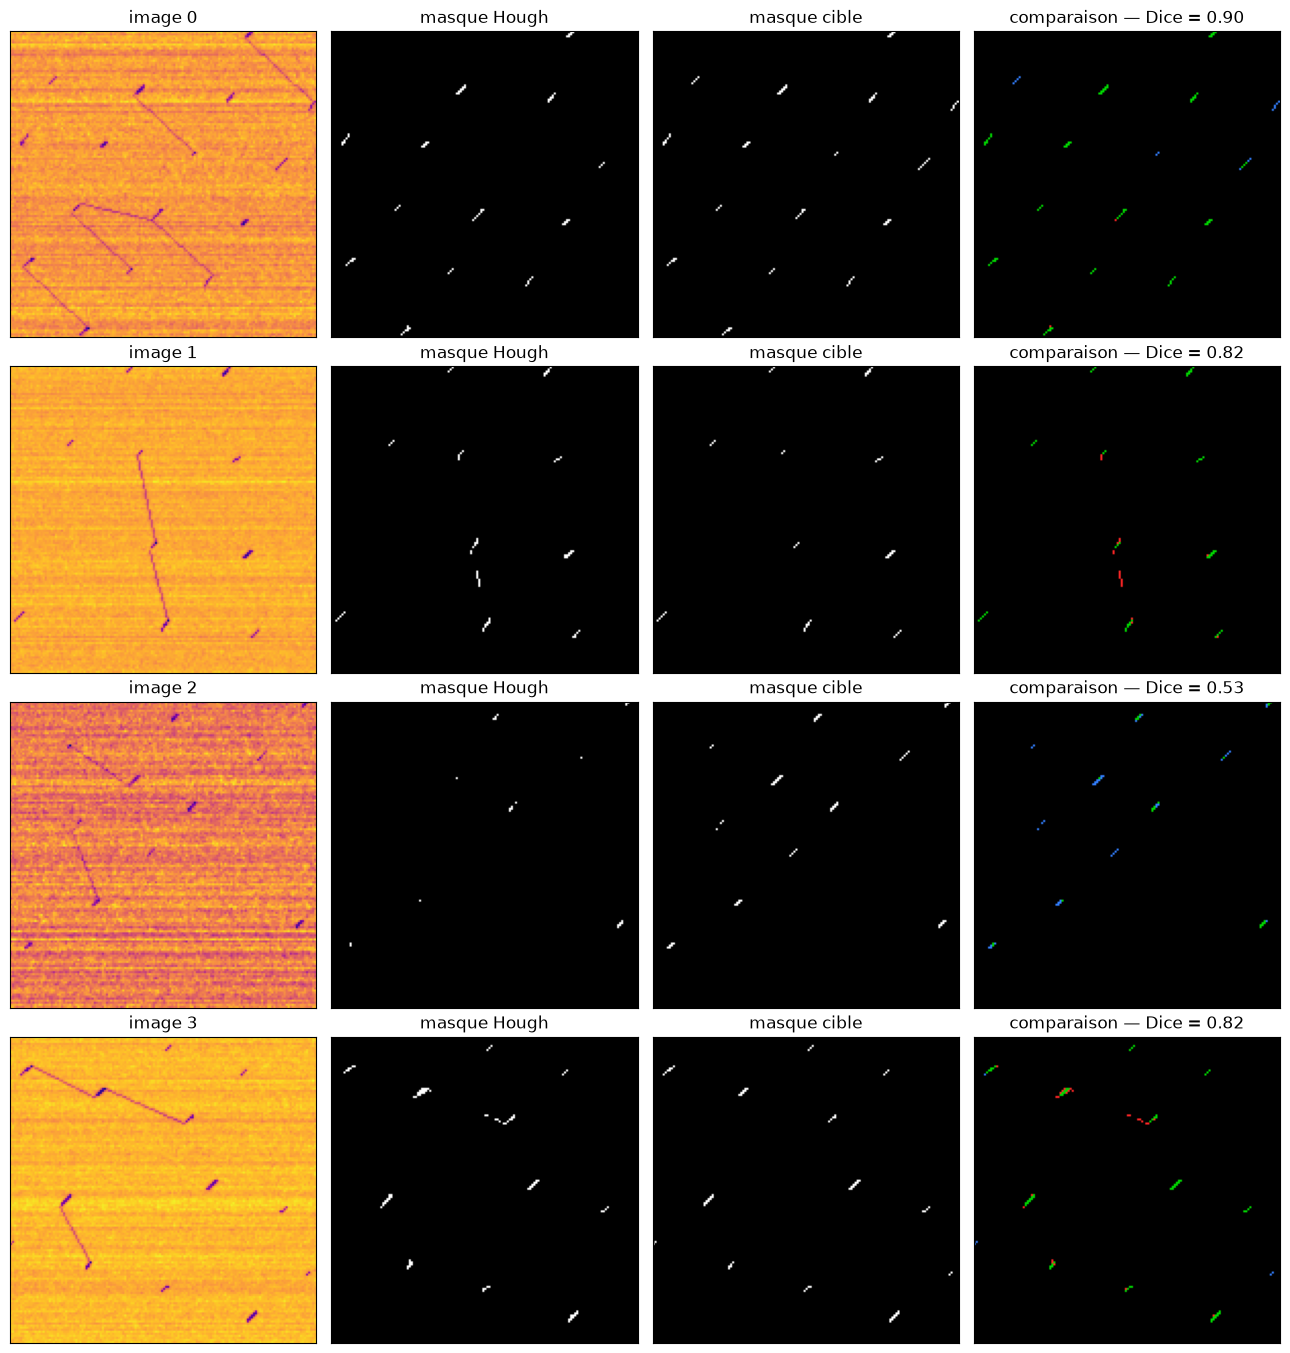

In [6]:
n_show = min(4, len(images))
fig, axes = plt.subplots(n_show, 4, figsize=(13, 3.4 * n_show), squeeze=False)
for row in range(n_show):
    pred = hough_mask(images[row], **BEST_PARAMS) > 0
    target = masks[row] > 0
    comparison = np.zeros((*target.shape, 3))
    comparison[pred & target] = (0.0, 0.85, 0.0)  # vrai positif
    comparison[pred & ~target] = (1.0, 0.15, 0.15)  # faux positif
    comparison[~pred & target] = (0.2, 0.5, 1.0)  # faux négatif

    axes[row, 0].imshow(images[row], origin="lower", cmap="plasma")
    axes[row, 0].set_title(f"image {row}")
    axes[row, 1].imshow(pred, origin="lower", cmap="gray")
    axes[row, 1].set_title("masque Hough")
    axes[row, 2].imshow(target, origin="lower", cmap="gray")
    axes[row, 2].set_title("masque cible")
    axes[row, 3].imshow(comparison, origin="lower")
    axes[row, 3].set_title(f"comparaison — Dice = {dice(pred, target):.2f}")
    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()
plt.show()

---
**Récap**

- `generate_dataset` → `load_dataset` → `images` / `masks` / `sticks` / `meta`.
- `hough_mask(image)` → masque prédit, comparé visuellement au masque cible.